In [ ]:
#Step 1: Download the Dataset
# https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset

In [ ]:
#Step 2: Upload and Load the Dataset in Google Colab
from google.colab import files
uploaded = files.upload()

Saving SOCR-HeightWeight.csv to SOCR-HeightWeight.csv


In [ ]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("SOCR-HeightWeight.csv")

# Display the first 5 rows
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


The output tells us that:

The dataset includes an Index column along with Height (Inches) and Weight (Pounds).

All values are numerical, i.e., the dataset is suitable for regression analysis.

No missing values can be seen, at least in the initial preview.

Shape of the dataset: (25000, 2)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Height(Inches)  25000 non-null  float64
 1   Weight(Pounds)  25000 non-null  float64
dtypes: float64(2)
memory usage: 390.8 KB
None

Missing Values:
Height(Inches)    0
Weight(Pounds)    0
dtype: int64


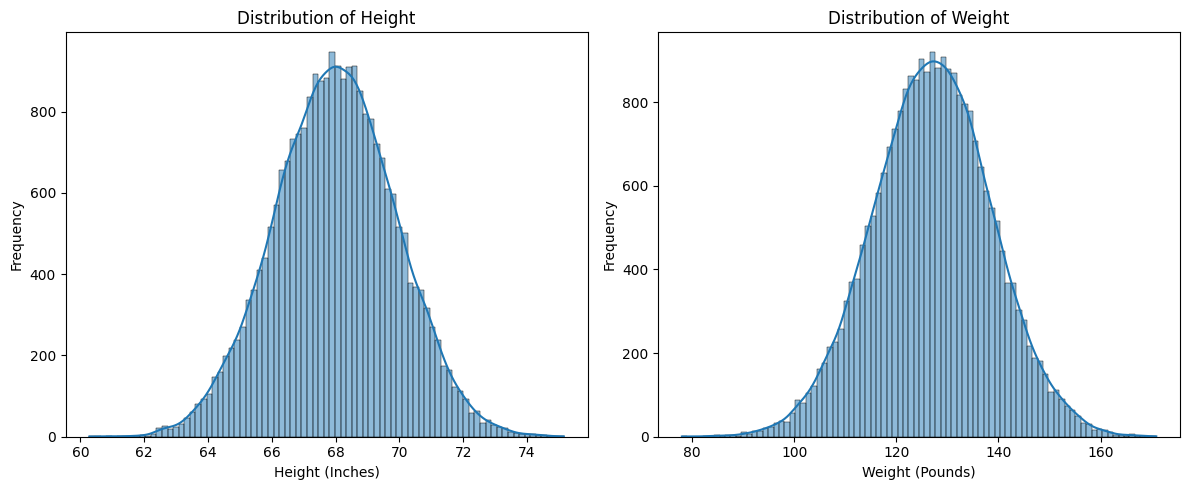

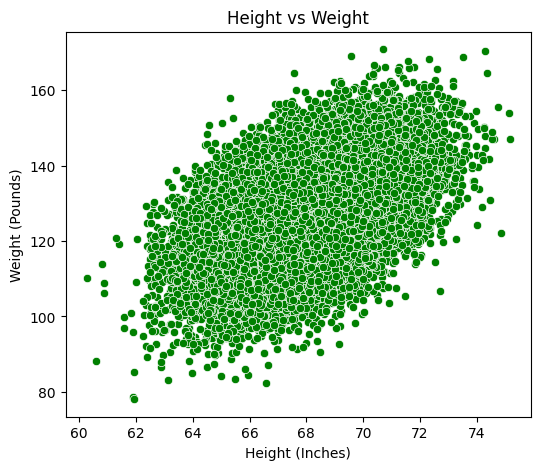

In [ ]:
#Step 3: Perform Exploratory Data Analysis (EDA)
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Shape of the dataset
print("Shape of the dataset:", df.shape)

# Basic info
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Histogram of Height
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Height(Inches)'], kde=True)
plt.title('Distribution of Height')
plt.xlabel('Height (Inches)')
plt.ylabel('Frequency')

# Histogram of Weight
plt.subplot(1, 2, 2)
sns.histplot(df['Weight(Pounds)'], kde=True)
plt.title('Distribution of Weight')
plt.xlabel('Weight (Pounds)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Scatter plot to show relationship
plt.figure(figsize=(6, 5))
sns.scatterplot(x='Height(Inches)', y='Weight(Pounds)', data=df, color='green')
plt.title('Height vs Weight')
plt.xlabel('Height (Inches)')
plt.ylabel('Weight (Pounds)')
plt.show()

The inference from output
*   There are 25,000 entries.
*   No missing values are there.

Three clean numeric columns are present:
 *   Index
 *   Height(Inches)
 *   Weight(Pounds)

The distribution plots for both height and weight are:
*   Symmetric and normally distributed
*   Free from visible outliers
*   The scatter plot (Height vs Weight) reveals a strong positive  linear relationship
  




   

   

   

In [ ]:
#Step 4: Data Preprocessing
# Drop the 'Index' column
df = df.drop('Index', axis=1)

# Separate features and target
X = df[['Height(Inches)']]   # Independent variable (feature)
y = df['Weight(Pounds)']     # Dependent variable (target)

In [ ]:
#Step 5: Train the Model (Linear Regression)
# Import libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
model = LinearRegression()

# Train both models
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Evaluate Linear Regression
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

# Print results
print("Linear Regression:")
print("  MSE:", mse)
print("  R² Score:", r2)

Linear Regression:
  MSE: 102.48790963792534
  R² Score: 0.26059113512888576


In [ ]:
new_height = [[79]]
predicted_weight = model.predict(new_height)

print("Predicted Weight:", predicted_weight[0])

Predicted Weight: 160.89149344641038


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Import libraries
from sklearn.ensemble import RandomForestRegressor

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train both models
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)

# Evaluate Random Forest
rf_mse = mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("\nRandom Forest Regressor:")
print("  MSE:", rf_mse)
print("  R² Score:", rf_r2)


Random Forest Regressor:
  MSE: 146.73119618890016
  R² Score: -0.05860630388999


In [ ]:
new_height = [[79]]
predicted_weight = rf_model.predict(new_height)

print("Predicted Weight:", predicted_weight[0])

Predicted Weight: 147.1383260000002


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
